# Compare the current SciPy and Pyomo joint-control optimizers

This tutorial reproduces the historical $A_1 \times K_C$ experiment in which both shelf temperature and chamber pressure are released. It uses the physics and APIs on current \`main\`, comparing the legacy sequential SciPy optimizer with an equivalent free-final-time Pyomo.DAE model transcribed by backward finite differences and LAGRANGE-RADAU orthogonal collocation. The headline comparison gives both DAE transformations the same number of transcription points.


## What is held equivalent?

| SciPy workflow | Pyomo.DAE workflow |
| --- | --- |
| Sequentially minimize $P_{ch}-P_{sub}$, maximizing rate at each cake state | Simultaneously minimize free final drying time |
| Advance the one cake-length ODE explicitly | Transcribe the same ODE with Pyomo.DAE |
| Stop at 100% dried | Constrain the terminal state to 100% dried |
| Optimize shelf temperature from -45 to 120 °C and chamber pressure from 50 to 500 mTorr | Optimize the same two controls with the same bounds |

With one monotone differential state and no intertemporal control penalty, maximizing sublimation rate at every state minimizes completion time. The comparison therefore uses final drying time as the common process objective. Finite differences and collocation are alternative algebraic reformulations of the same DAE, not different physical models.


## Optional solver setup

Run this notebook from the repository root after installing the optional stack:

\`\`\`bash
python -m pip install -e ".[dev,pyomo]"
idaes get-extensions --extra petsc
export PATH="$HOME/.idaes/bin:$PATH"
jupyter lab docs/examples/current_main_joint_optimizer_comparison.ipynb
\`\`\`

A conda-forge IPOPT installation can be used instead. The full default grid takes several minutes because every SciPy reference advances with the configured fine time step and timing is repeated.


In [1]:
# Papermill parameters: CI overrides these with a small smoke case.
a1_values = [16.0, 18.0, 20.0]
kc_values = [2.75e-4, 3.30e-4, 4.00e-4]
scipy_dt = 0.01
scipy_dt_values = [0.1, 0.05, 0.02, 0.01]
point_budget = 25
ncp = 3
final_dried_fraction = 1.0
timing_repeats = 3
sensitivity_point_budgets = [25, 49, 73]
constraint_tolerance = 1.0e-4
save_results = False
results_dir = "benchmarks/results/current_main_joint_comparison"


In [2]:
import json
import platform
import subprocess
from importlib.metadata import version
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pyomo
import scipy

from examples.current_main_joint_optimizer_comparison import (
    comparison_inputs,
    matched_nfe_for_point_budget,
    run_case_comparison,
    run_discretization_sensitivity,
    run_pyomo_dae,
    run_scipy_reference,
)
from lyopronto import constant


In [3]:
try:
    git_revision = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], text=True
    ).strip()
except (OSError, subprocess.CalledProcessError):
    git_revision = "unavailable"

environment = {
    "git_revision": git_revision,
    "python": platform.python_version(),
    "platform": platform.platform(),
    "lyopronto": version("lyopronto"),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "pyomo": pyomo.__version__,
    "matplotlib": matplotlib.__version__,
}
environment


{'git_revision': 'd0a8042943223229f50168d1328439f8db3d05d2',
 'python': '3.13.5',
 'platform': 'Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.39',
 'lyopronto': '1.1.0',
 'numpy': '2.5.0',
 'scipy': '1.17.1',
 'pyomo': '6.9.5',
 'matplotlib': '3.10.9'}

## Experimental protocol

For each $(A_1, K_C)$ pair, the helper performs three equivalent runs:

1. Run \`opt_Pch_Tsh.dry\` to 100% dried using the configured sequential step.
2. Solve the free-final-time joint Pyomo.DAE model with \`dae.finite_difference\` and the \`BACKWARD\` scheme.
3. Solve the same model with \`dae.collocation\` and the \`LAGRANGE-RADAU\` scheme.
4. Require every workflow to reach the same configured terminal dried fraction.
5. Compare the final-time objectives directly and report median end-to-end wall times.

The default timing is a cold-start, workflow-level comparison: model construction and IPOPT solve are included, while an untimed warm-up removes one-time import and executable startup costs. Collocation uses \`nfe * ncp + 1\` time points, whereas finite differences use \`nfe + 1\`. Separate \`nfe\` values give both DAE transformations exactly \`point_budget\` time points. Scalar-variable and active-constraint counts are also reported because equal point counts are only a first approximation to equal NLP size.


In [4]:
# Pay one-time Pyomo/IPOPT initialization before collecting timings.
for method in ("finite_difference", "collocation"):
    warmup = run_pyomo_dae(
        a1_values[0], kc_values[0], discretization=method, nfe=4, ncp=ncp
    )
    assert warmup.success, (method, warmup.solver_status, warmup.termination_condition)


In [5]:
finite_difference_nfe, collocation_nfe = matched_nfe_for_point_budget(
    point_budget, ncp
)
print(
    f"Matched DAE budget: {point_budget} points "
    f"(FD nfe={finite_difference_nfe}; "
    f"collocation nfe={collocation_nfe}, ncp={ncp})"
)

comparisons = []
for a1 in a1_values:
    for kc in kc_values:
        print(f"Running A1={a1:g}, KC={kc:.2e} ...")
        comparisons.append(
            run_case_comparison(
                a1,
                kc,
                scipy_dt=scipy_dt,
                finite_difference_nfe=finite_difference_nfe,
                collocation_nfe=collocation_nfe,
                ncp=ncp,
                final_dried_fraction=final_dried_fraction,
                timing_repeats=timing_repeats,
            )
        )

case_by_parameter = {(case.a1, case.kc): case for case in comparisons}
print(f"Completed {len(comparisons)} grid cases.")


Matched DAE budget: 25 points (FD nfe=24; collocation nfe=8, ncp=3)
Running A1=16, KC=2.75e-04 ...


Running A1=16, KC=3.30e-04 ...


Running A1=16, KC=4.00e-04 ...


Running A1=18, KC=2.75e-04 ...


Running A1=18, KC=3.30e-04 ...


Running A1=18, KC=4.00e-04 ...


Running A1=20, KC=2.75e-04 ...


Running A1=20, KC=3.30e-04 ...


Running A1=20, KC=4.00e-04 ...


Completed 9 grid cases.


In [6]:
header = (
    f"{'A1':>5} {'KC':>10} {'method':>20} {'time [h]':>10} "
    f"{'gap [%]':>10} {'wall [s]':>11} {'speedup':>10} "
    f"{'points/steps':>12} {'variables':>10} {'constraints':>12} "
    f"{'iterations':>11}"
)
print(header)
print("-" * len(header))
for case in comparisons:
    print(
        f"{case.a1:5.1f} {case.kc:10.2e} {'SciPy':>20} "
        f"{case.scipy_objective_time_hr:10.4f} {0.0:10.3f} "
        f"{case.scipy_wall_median_s:11.3f} {1.0:10.1f} "
        f"{case.scipy_trajectory.shape[0]:12d} "
        f"{'-':>10} {'-':>12} {'-':>11}"
    )
    rows = [
        (
            "finite difference",
            case.finite_difference_objective_time_hr,
            case.finite_difference_objective_gap_percent,
            case.finite_difference_wall_median_s,
            case.finite_difference_speedup,
            case.finite_difference_trajectory,
            case.finite_difference_n_variables,
            case.finite_difference_n_constraints,
            case.finite_difference_solver_iterations,
        ),
        (
            "collocation",
            case.collocation_objective_time_hr,
            case.collocation_objective_gap_percent,
            case.collocation_wall_median_s,
            case.collocation_speedup,
            case.collocation_trajectory,
            case.collocation_n_variables,
            case.collocation_n_constraints,
            case.collocation_solver_iterations,
        ),
    ]
    for method, objective, gap, wall, speedup, table, nvars, ncons, iterations in rows:
        iteration_text = "-" if iterations is None else str(iterations)
        print(
            f"{case.a1:5.1f} {case.kc:10.2e} {method:>20} "
            f"{objective:10.4f} {gap:10.3f} {wall:11.3f} "
            f"{speedup:10.1f} {table.shape[0]:12d} {nvars:10d} "
            f"{ncons:12d} {iteration_text:>11}"
        )


   A1         KC               method   time [h]    gap [%]    wall [s]    speedup points/steps  variables  constraints  iterations
-----------------------------------------------------------------------------------------------------------------------------------
 16.0   2.75e-04                SciPy    10.7518      0.000       4.202        1.0         1077          -            -           -
 16.0   2.75e-04    finite difference    11.1255      3.475       0.061       69.0           25        251          253           -
 16.0   2.75e-04          collocation    10.7608      0.083       0.047       89.9           25        251          253           -
 16.0   3.30e-04                SciPy    10.7518      0.000       4.092        1.0         1077          -            -           -
 16.0   3.30e-04    finite difference    11.1255      3.475       0.069       58.9           25        251          253           -
 16.0   3.30e-04          collocation    10.7608      0.083       0.062     

## Validate before interpreting

An \`optimal\` solver termination is not sufficient by itself. The experiment also checks the final drying target, finite seven-column outputs, both control bounds, the product-temperature limit, initial-node right-limit convention, and current Pyomo constraint residuals. Legacy output pressure remains in mTorr and percent dried remains on a 0–100 scale.


In [7]:
for case in comparisons:
    assert case.scipy_trajectory.shape[1] == 7
    assert case.finite_difference_trajectory.shape == (point_budget, 7)
    assert case.collocation_trajectory.shape == (point_budget, 7)
    assert np.all(np.isfinite(case.scipy_trajectory))
    assert np.all(np.isfinite(case.finite_difference_trajectory))
    assert np.all(np.isfinite(case.collocation_trajectory))
    for table in (
        case.finite_difference_trajectory,
        case.collocation_trajectory,
    ):
        assert table[-1, 6] >= 100.0 * final_dried_fraction - 1.0e-3
        assert np.max(table[:, 2]) <= -25.0 + 1.0e-4
        assert np.min(table[:, 3]) >= -45.0 - 1.0e-4
        assert np.max(table[:, 3]) <= 120.0 + 1.0e-4
        assert np.min(table[:, 4]) >= 50.0 - 1.0e-3
        assert np.max(table[:, 4]) <= 500.0 + 1.0e-3
        assert np.isclose(table[0, 3], table[1, 3], atol=1.0e-4)
        assert np.isclose(table[0, 4], table[1, 4], atol=1.0e-3)
    assert case.finite_difference_max_constraint_violation <= constraint_tolerance
    assert case.collocation_max_constraint_violation <= constraint_tolerance

print("All grid cases satisfy the experiment acceptance checks.")


All grid cases satisfy the experiment acceptance checks.


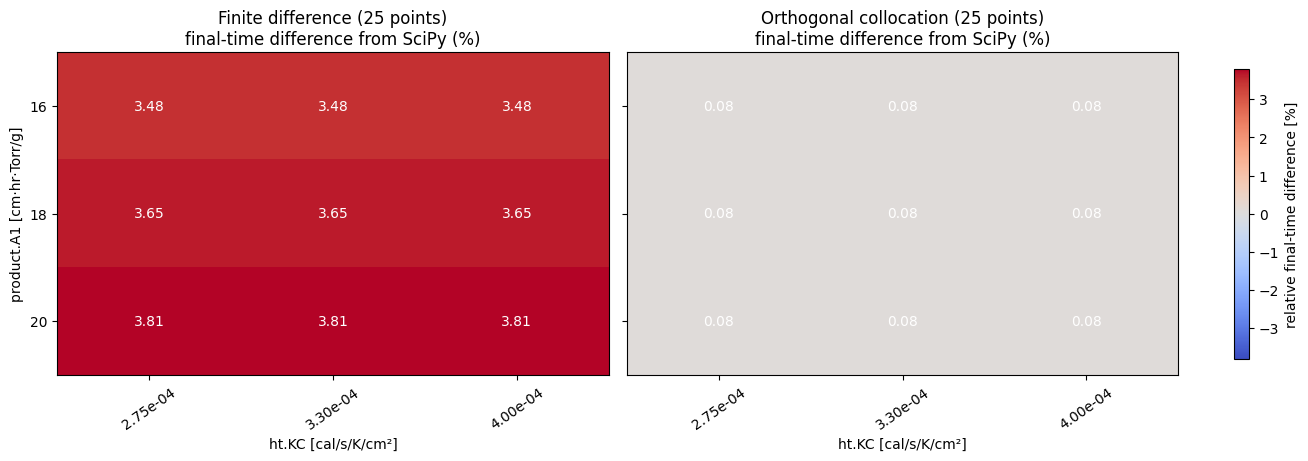

In [8]:
def matrix_for(attribute):
    return np.array(
        [
            [
                getattr(
                    case_by_parameter[(float(a1), float(kc))],
                    attribute,
                )
                for kc in kc_values
            ]
            for a1 in a1_values
        ],
        dtype=float,
    )


def annotate_heatmap(ax, values, fmt):
    threshold = 0.55 * np.nanmax(np.abs(values))
    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            color = "white" if abs(values[row, col]) > threshold else "black"
            ax.text(
                col,
                row,
                format(values[row, col], fmt),
                ha="center",
                va="center",
                color=color,
            )


objective_gap_matrices = [
    (
        "Finite difference",
        matrix_for("finite_difference_objective_gap_percent"),
    ),
    (
        "Orthogonal collocation",
        matrix_for("collocation_objective_gap_percent"),
    ),
]
limit = max(
    1.0,
    max(float(np.max(np.abs(values))) for _, values in objective_gap_matrices),
)
fig, axes = plt.subplots(
    1, 2, figsize=(13, 4.5), sharey=True, layout="constrained"
)
for ax, (label, values) in zip(axes, objective_gap_matrices):
    image = ax.imshow(
        values,
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit,
        aspect="auto",
    )
    ax.set(
        title=(
            f"{label} ({point_budget} points)\n"
            "final-time difference from SciPy (%)"
        ),
        xlabel="ht.KC [cal/s/K/cm²]",
    )
    ax.set_xticks(
        range(len(kc_values)),
        [f"{value:.2e}" for value in kc_values],
        rotation=35,
    )
    ax.set_yticks(
        range(len(a1_values)),
        [f"{value:g}" for value in a1_values],
    )
    annotate_heatmap(ax, values, ".2f")
axes[0].set_ylabel("product.A1 [cm·hr·Torr/g]")
fig.colorbar(
    image,
    ax=axes,
    label="relative final-time difference [%]",
    shrink=0.9,
)
plt.show()


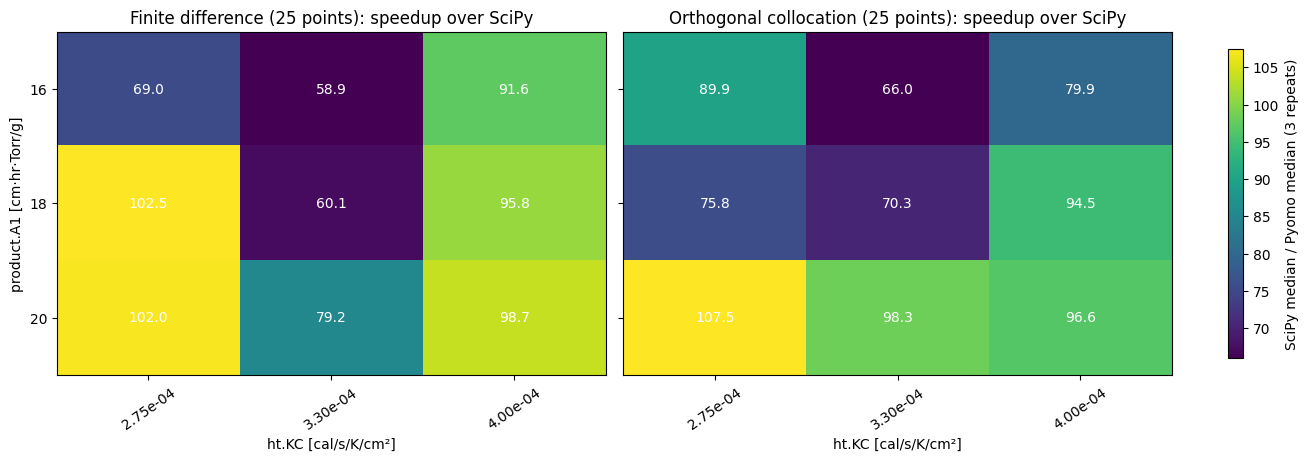

In [9]:
speedup_matrices = [
    ("Finite difference", matrix_for("finite_difference_speedup")),
    ("Orthogonal collocation", matrix_for("collocation_speedup")),
]
fig, axes = plt.subplots(
    1, 2, figsize=(13, 4.5), sharey=True, layout="constrained"
)
for ax, (label, values) in zip(axes, speedup_matrices):
    image = ax.imshow(values, cmap="viridis", aspect="auto")
    ax.set(
        title=f"{label} ({point_budget} points): speedup over SciPy",
        xlabel="ht.KC [cal/s/K/cm²]",
    )
    ax.set_xticks(
        range(len(kc_values)),
        [f"{value:.2e}" for value in kc_values],
        rotation=35,
    )
    ax.set_yticks(
        range(len(a1_values)),
        [f"{value:g}" for value in a1_values],
    )
    annotate_heatmap(ax, values, ".1f")
axes[0].set_ylabel("product.A1 [cm·hr·Torr/g]")
fig.colorbar(
    image,
    ax=axes,
    label=f"SciPy median / Pyomo median ({timing_repeats} repeats)",
    shrink=0.9,
)
plt.show()


The speedup values are machine- and environment-dependent. They scale roughly with $1/\mathtt{scipy\_dt}$ because \`opt_Pch_Tsh.dry\` performs one SLSQP solve per sequential step, while changing \`scipy_dt\` does not change the DAE workload. SciPy step count and simultaneous NLP point count are therefore both reported but are not equivalent measures of problem size. Objective gaps, convergence trends, and physical acceptance checks are the portable numerical results.

In this joint problem the pressure optimum is expected to spend substantial time at the 50 mTorr lower bound, while shelf temperature adjusts to keep the product-temperature constraint active. That behavior is a result of the optimization, not an imposed control profile.


## SciPy step-size convergence

SciPy is a sequential optimizer/integrator, not a simultaneous transcription, so its number of steps should not be matched to the DAE point budget. Instead, this study quantifies the final-time reference's sensitivity to \`dt\`. The configured grid reference must be the finest value listed here. Differences comparable to the change between the two finest steps are within the SciPy reference resolution.


    dt [h]    steps     time [h]   gap from finest [%]   wall [s]
    0.1000      108     10.67333               -0.7303      0.422
    0.0500      216     10.71734               -0.3210      0.834
    0.0200      539     10.74327               -0.0797      2.088
    0.0100     1077     10.75185                0.0000      4.202


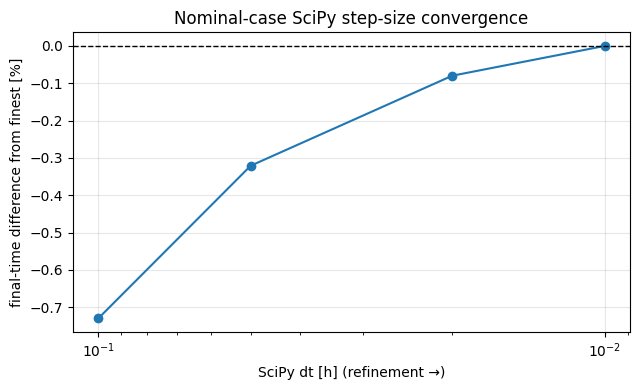

In [10]:
nominal = case_by_parameter[
    (float(a1_values[0]), float(kc_values[0]))
]
scipy_dt_values = sorted(
    {float(value) for value in scipy_dt_values},
    reverse=True,
)
assert all(value > 0.0 for value in scipy_dt_values)
assert np.isclose(scipy_dt, min(scipy_dt_values))

scipy_convergence_rows = []
for dt in scipy_dt_values:
    if np.isclose(dt, scipy_dt):
        objective_time_hr = nominal.scipy_objective_time_hr
        wall_time_s = nominal.scipy_wall_median_s
        n_steps = nominal.scipy_trajectory.shape[0]
    else:
        run = run_scipy_reference(nominal.a1, nominal.kc, dt=dt)
        assert run.success
        objective_time_hr = run.objective_time_hr
        wall_time_s = run.wall_time_s
        n_steps = run.n_time_points
    scipy_convergence_rows.append(
        {
            "dt": dt,
            "objective_time_hr": objective_time_hr,
            "wall_time_s": wall_time_s,
            "n_steps": n_steps,
        }
    )

finest_time = scipy_convergence_rows[-1]["objective_time_hr"]
for row in scipy_convergence_rows:
    row["gap_from_finest_percent"] = (
        100.0
        * (row["objective_time_hr"] - finest_time)
        / finest_time
    )

print(
    f"{'dt [h]':>10} {'steps':>8} {'time [h]':>12} "
    f"{'gap from finest [%]':>21} {'wall [s]':>10}"
)
for row in scipy_convergence_rows:
    print(
        f"{row['dt']:10.4f} {row['n_steps']:8d} "
        f"{row['objective_time_hr']:12.5f} "
        f"{row['gap_from_finest_percent']:21.4f} "
        f"{row['wall_time_s']:10.3f}"
    )

fig, ax = plt.subplots(figsize=(6.5, 4.0))
ax.plot(
    [row["dt"] for row in scipy_convergence_rows],
    [row["gap_from_finest_percent"] for row in scipy_convergence_rows],
    marker="o",
)
ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--")
ax.set_xscale("log")
ax.invert_xaxis()
ax.set(
    xlabel="SciPy dt [h] (refinement →)",
    ylabel="final-time difference from finest [%]",
    title="Nominal-case SciPy step-size convergence",
)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## DAE transcription sensitivity

The two transformations have different approximation orders and therefore should not be compared at the same \`nfe\`. Each pair below uses exactly the same number of transcription points: finite differences use \`point_budget - 1\` elements, while collocation uses \`(point_budget - 1) / ncp\`. The plots show accuracy against point count, scalar NLP variables, and end-to-end wall time.


              method    nfe  points  variables  constraints  iterations  objective gap [%]   wall [s]   max residual
   finite_difference     24      25        251          253           -              3.475      0.077      2.498e-07
         collocation      8      25        251          253           -              0.083      0.073      1.278e-07
   finite_difference     48      49        491          493           -              1.811      0.094      2.496e-07
         collocation     16      49        491          493           -              0.080      0.092      8.077e-09
   finite_difference     72      73        731          733           -              1.243      0.088      2.494e-07
         collocation     24      73        731          733           -              0.079      0.113      1.342e-07


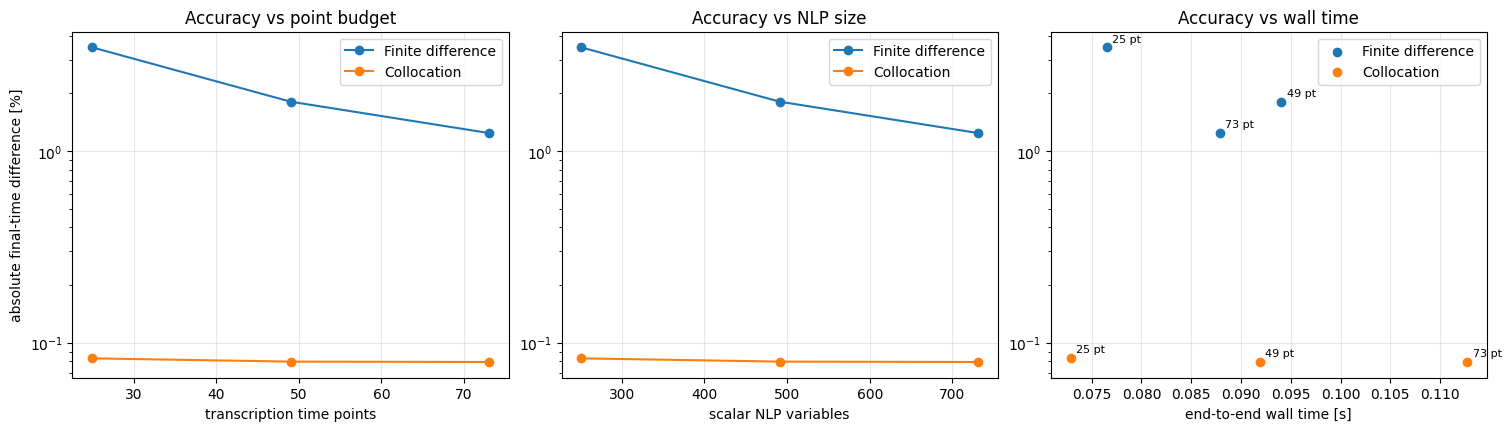

In [11]:
sensitivity_rows = run_discretization_sensitivity(
    nominal.a1,
    nominal.kc,
    nominal.scipy_trajectory,
    point_budgets=sensitivity_point_budgets,
    ncp=ncp,
    final_dried_fraction=final_dried_fraction,
)

print(
    f"{'method':>20} {'nfe':>6} {'points':>7} "
    f"{'variables':>10} {'constraints':>12} {'iterations':>11} "
    f"{'objective gap [%]':>18} {'wall [s]':>10} "
    f"{'max residual':>14}"
)
for row in sensitivity_rows:
    iteration_text = (
        "-" if row["solver_iterations"] is None
        else str(row["solver_iterations"])
    )
    print(
        f"{row['method']:>20} {row['nfe']:6d} "
        f"{row['n_time_points']:7d} {row['n_variables']:10d} "
        f"{row['n_constraints']:12d} {iteration_text:>11} "
        f"{row['objective_gap_percent']:18.3f} "
        f"{row['wall_time_s']:10.3f} "
        f"{row['max_constraint_violation']:14.3e}"
    )

fig, axes = plt.subplots(
    1, 3, figsize=(15, 4.2), layout="constrained"
)
for method, label in [
    ("finite_difference", "Finite difference"),
    ("collocation", "Collocation"),
]:
    rows = [row for row in sensitivity_rows if row["method"] == method]
    error = [
        max(abs(row["objective_gap_percent"]), 1.0e-6)
        for row in rows
    ]
    axes[0].plot(
        [row["n_time_points"] for row in rows],
        error,
        marker="o",
        label=label,
    )
    axes[1].plot(
        [row["n_variables"] for row in rows],
        error,
        marker="o",
        label=label,
    )
    axes[2].scatter(
        [row["wall_time_s"] for row in rows],
        error,
        label=label,
    )
    for row, value in zip(rows, error):
        axes[2].annotate(
            f"{row['n_time_points']} pt",
            (row["wall_time_s"], value),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )
axes[0].set(
    xlabel="transcription time points",
    ylabel="absolute final-time difference [%]",
    title="Accuracy vs point budget",
)
axes[1].set(
    xlabel="scalar NLP variables",
    title="Accuracy vs NLP size",
)
axes[2].set(
    xlabel="end-to-end wall time [s]",
    title="Accuracy vs wall time",
)
for ax in axes:
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
    ax.legend()
plt.show()


## Nominal trajectory comparison

All three results retain the legacy seven-column output shape. Shelf temperature is column 3, pressure is column 4 in mTorr, and drying progress is column 6 on the 0–100 percent scale.

Both DAE controls at the isolated $t=0$ node have zero measure in the final-time objective. The joint model constrains each endpoint to equal its first positive-time value. This selects the right-limit representative in the raw result itself and prevents the arbitrary initial control and temperature spikes seen in the historical plot. No display-only smoothing is applied.


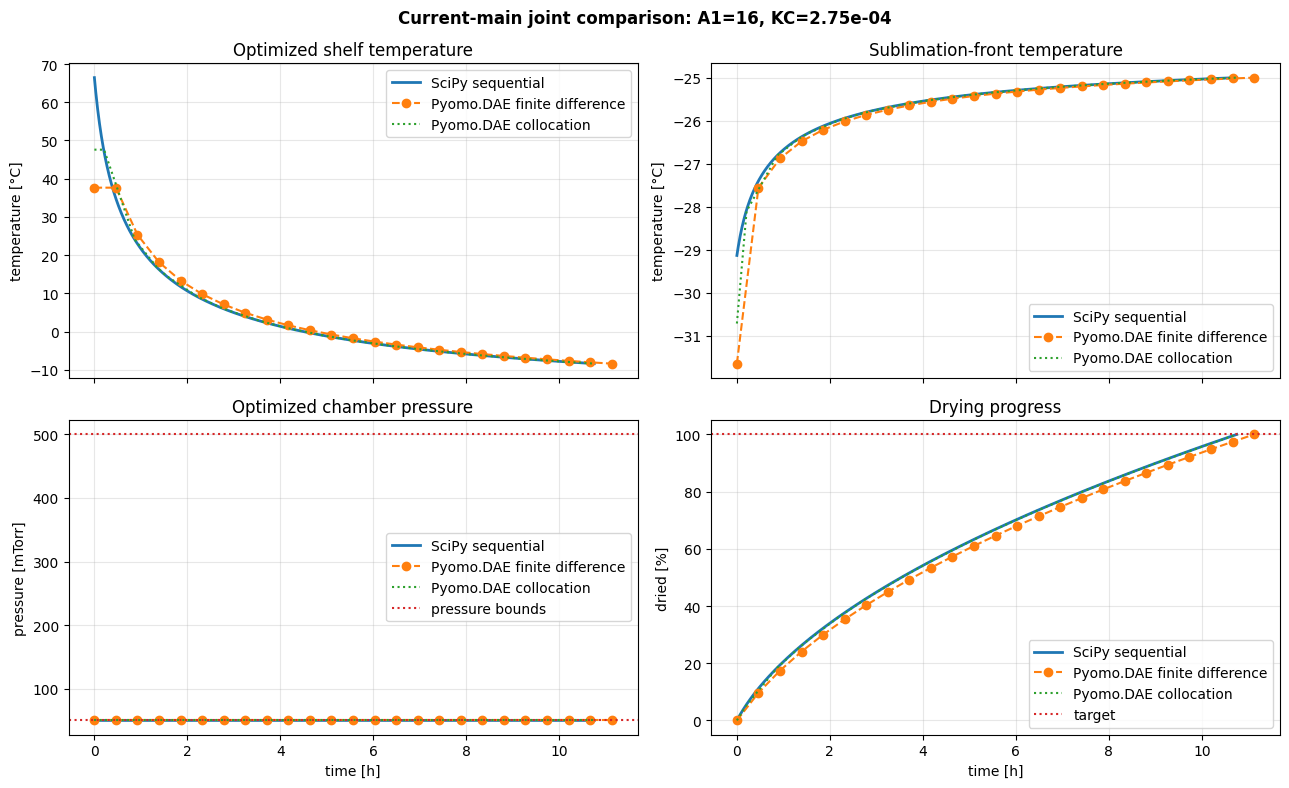

In [12]:
scipy_table = nominal.scipy_trajectory
finite_difference_table = nominal.finite_difference_trajectory
collocation_table = nominal.collocation_trajectory

trajectory_styles = [
    (scipy_table, "SciPy sequential", {"linewidth": 2.0}),
    (
        finite_difference_table,
        "Pyomo.DAE finite difference",
        {"linestyle": "--", "marker": "o"},
    ),
    (
        collocation_table,
        "Pyomo.DAE collocation",
        {"linestyle": ":"},
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for table, label, style in trajectory_styles:
    axes[0, 0].plot(
        table[:, 0], table[:, 3], label=label, **style
    )
    axes[0, 1].plot(
        table[:, 0], table[:, 1], label=label, **style
    )
    axes[1, 0].plot(
        table[:, 0], table[:, 4], label=label, **style
    )
    axes[1, 1].plot(
        table[:, 0], table[:, 6], label=label, **style
    )

axes[0, 0].set(
    title="Optimized shelf temperature",
    ylabel="temperature [°C]",
)
axes[0, 1].set(
    title="Sublimation-front temperature",
    ylabel="temperature [°C]",
)
axes[1, 0].set(
    title="Optimized chamber pressure",
    xlabel="time [h]",
    ylabel="pressure [mTorr]",
)
axes[1, 0].axhline(
    50.0, color="tab:red", linestyle=":", label="pressure bounds"
)
axes[1, 0].axhline(500.0, color="tab:red", linestyle=":")
axes[1, 1].set(
    title="Drying progress",
    xlabel="time [h]",
    ylabel="dried [%]",
)
axes[1, 1].axhline(
    100.0 * final_dried_fraction,
    color="tab:red",
    linestyle=":",
    label="target",
)
for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle(
    f"Current-main joint comparison: "
    f"A1={nominal.a1:g}, KC={nominal.kc:.2e}",
    fontweight="bold",
)
fig.tight_layout()
plt.show()


## Sublimation-rate and temperature analysis

The historical experiment also inspected sublimation flux and vial-bottom temperature. The faded curves in the second panel are the corresponding optimized shelf-temperature controls, included only as a visual reference. The product constraint is applied to vial-bottom temperature, not sublimation-front temperature.


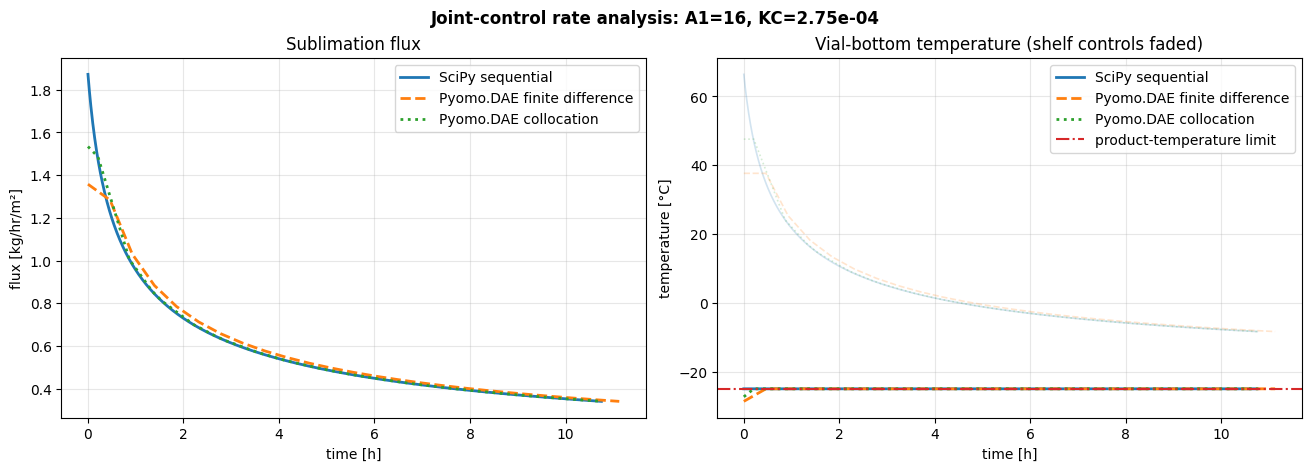

In [13]:
colors = ["tab:blue", "tab:orange", "tab:green"]
labels = [
    "SciPy sequential",
    "Pyomo.DAE finite difference",
    "Pyomo.DAE collocation",
]
tables = [
    scipy_table,
    finite_difference_table,
    collocation_table,
]
line_styles = ["-", "--", ":"]

fig, axes = plt.subplots(
    1, 2, figsize=(13, 4.6), layout="constrained"
)
for table, label, color, linestyle in zip(
    tables, labels, colors, line_styles
):
    axes[0].plot(
        table[:, 0],
        table[:, 5],
        label=label,
        color=color,
        linestyle=linestyle,
        linewidth=2.0,
    )
    axes[1].plot(
        table[:, 0],
        table[:, 2],
        label=label,
        color=color,
        linestyle=linestyle,
        linewidth=2.0,
    )
    axes[1].plot(
        table[:, 0],
        table[:, 3],
        color=color,
        linestyle=linestyle,
        alpha=0.2,
        linewidth=1.2,
    )

axes[0].set(
    title="Sublimation flux",
    xlabel="time [h]",
    ylabel="flux [kg/hr/m²]",
)
axes[1].set(
    title="Vial-bottom temperature (shelf controls faded)",
    xlabel="time [h]",
    ylabel="temperature [°C]",
)
axes[1].axhline(
    -25.0,
    color="tab:red",
    linestyle="-.",
    label="product-temperature limit",
)
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle(
    f"Joint-control rate analysis: "
    f"A1={nominal.a1:g}, KC={nominal.kc:.2e}",
    fontweight="bold",
)
plt.show()


## Constraint activity

The left panel uses the physically enforced operating plane: vial-bottom temperature versus shelf temperature. The shaded region violates the current $T_{bot} \leq -25\,^{\circ}$C product limit. The right panel evaluates the equipment-capability margin $a + bP_{ch} - n_{vial}\dot m$ from each exported trajectory; feasible values are nonnegative.


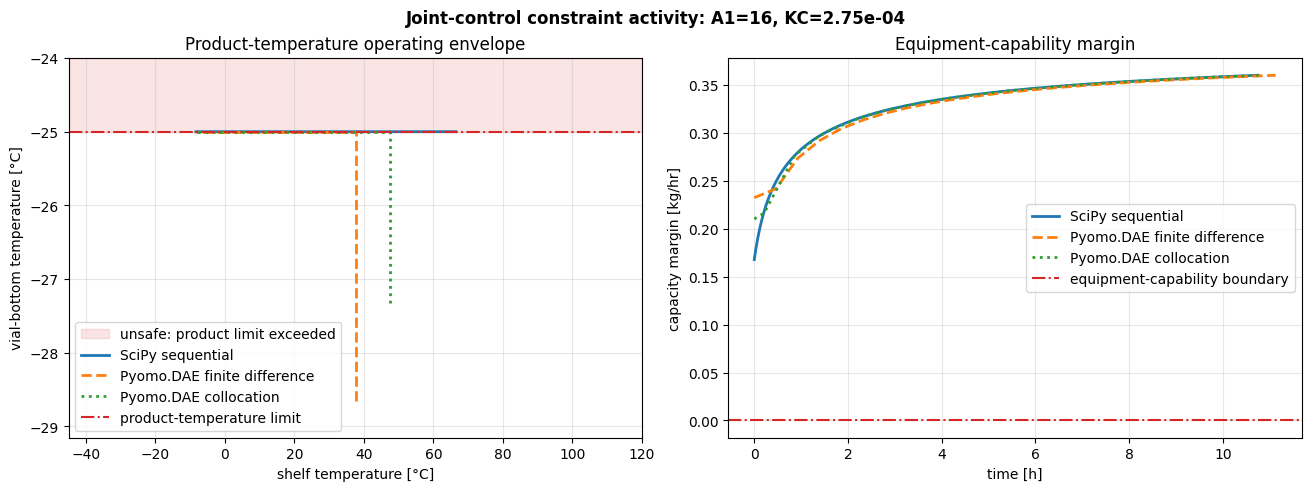

In [14]:
data = comparison_inputs(nominal.a1, nominal.kc)
temperature_min = min(float(np.min(table[:, 2])) for table in tables)
temperature_max = max(
    -24.0,
    max(float(np.max(table[:, 2])) for table in tables) + 0.5,
)

fig, axes = plt.subplots(
    1, 2, figsize=(13, 4.8), layout="constrained"
)
axes[0].axhspan(
    data["product"]["T_pr_crit"],
    temperature_max,
    color="tab:red",
    alpha=0.12,
    label="unsafe: product limit exceeded",
)
for table, label, color, linestyle in zip(
    tables, labels, colors, line_styles
):
    axes[0].plot(
        table[:, 3],
        table[:, 2],
        label=label,
        color=color,
        linestyle=linestyle,
        linewidth=2.0,
    )
    pch_torr = table[:, 4] / constant.Torr_to_mTorr
    dmdt = (
        table[:, 5]
        * data["vial"]["Ap"]
        * constant.cm_To_m**2
    )
    equipment_margin = (
        data["eq_cap"]["a"]
        + data["eq_cap"]["b"] * pch_torr
        - data["nvial"] * dmdt
    )
    axes[1].plot(
        table[:, 0],
        equipment_margin,
        label=label,
        color=color,
        linestyle=linestyle,
        linewidth=2.0,
    )

axes[0].axhline(
    data["product"]["T_pr_crit"],
    color="tab:red",
    linestyle="-.",
    label="product-temperature limit",
)
axes[0].set(
    xlim=(data["tshelf"]["min"], data["tshelf"]["max"]),
    ylim=(temperature_min - 0.5, temperature_max),
    xlabel="shelf temperature [°C]",
    ylabel="vial-bottom temperature [°C]",
    title="Product-temperature operating envelope",
)
axes[1].axhline(
    0.0,
    color="tab:red",
    linestyle="-.",
    label="equipment-capability boundary",
)
axes[1].set(
    xlabel="time [h]",
    ylabel="capacity margin [kg/hr]",
    title="Equipment-capability margin",
)
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle(
    f"Joint-control constraint activity: "
    f"A1={nominal.a1:g}, KC={nominal.kc:.2e}",
    fontweight="bold",
)
plt.show()


## Optionally save a compact reproduction record

Generated experiment outputs belong under \`benchmarks/results/\`, which is ignored by default. The JSON file contains environment and scalar summaries; the compressed NumPy archive retains every trajectory used for the plots.


In [15]:
if save_results:
    destination = Path(results_dir)
    destination.mkdir(parents=True, exist_ok=True)
    summaries = [
        {
            "A1": case.a1,
            "KC": case.kc,
            "scipy_objective_time_hr": case.scipy_objective_time_hr,
            "finite_difference_objective_time_hr": (
                case.finite_difference_objective_time_hr
            ),
            "collocation_objective_time_hr": (
                case.collocation_objective_time_hr
            ),
            "finite_difference_objective_gap_percent": (
                case.finite_difference_objective_gap_percent
            ),
            "collocation_objective_gap_percent": (
                case.collocation_objective_gap_percent
            ),
            "scipy_wall_times_s": list(case.scipy_wall_times_s),
            "finite_difference_wall_times_s": list(
                case.finite_difference_wall_times_s
            ),
            "collocation_wall_times_s": list(
                case.collocation_wall_times_s
            ),
            "finite_difference_speedup": (
                case.finite_difference_speedup
            ),
            "collocation_speedup": case.collocation_speedup,
            "finite_difference_n_variables": (
                case.finite_difference_n_variables
            ),
            "finite_difference_n_constraints": (
                case.finite_difference_n_constraints
            ),
            "finite_difference_solver_iterations": (
                case.finite_difference_solver_iterations
            ),
            "collocation_n_variables": (
                case.collocation_n_variables
            ),
            "collocation_n_constraints": (
                case.collocation_n_constraints
            ),
            "collocation_solver_iterations": (
                case.collocation_solver_iterations
            ),
            "finite_difference_max_constraint_violation": (
                case.finite_difference_max_constraint_violation
            ),
            "collocation_max_constraint_violation": (
                case.collocation_max_constraint_violation
            ),
        }
        for case in comparisons
    ]
    payload = {
        "environment": environment,
        "parameters": {
            "scipy_dt": scipy_dt,
            "scipy_dt_values": scipy_dt_values,
            "point_budget": point_budget,
            "finite_difference_nfe": finite_difference_nfe,
            "collocation_nfe": collocation_nfe,
            "ncp": ncp,
            "final_dried_fraction": final_dried_fraction,
            "timing_repeats": timing_repeats,
        },
        "cases": summaries,
        "scipy_convergence": scipy_convergence_rows,
        "discretization_sensitivity": sensitivity_rows,
    }
    (destination / "summary.json").write_text(
        json.dumps(payload, indent=2) + "\n"
    )
    trajectories = {}
    for case in comparisons:
        key = (
            f"A1_{case.a1:g}_KC_{case.kc:.2e}"
            .replace(".", "p")
            .replace("-", "m")
        )
        trajectories[f"{key}_scipy"] = case.scipy_trajectory
        trajectories[f"{key}_finite_difference"] = (
            case.finite_difference_trajectory
        )
        trajectories[f"{key}_collocation"] = (
            case.collocation_trajectory
        )
    np.savez_compressed(
        destination / "trajectories.npz",
        **trajectories,
    )
    print(f"Saved reproduction record under {destination}")
else:
    print("Set save_results=True to write JSON and NPZ outputs.")


Set save_results=True to write JSON and NPZ outputs.


## Interpretation boundaries

This notebook reproduces the scientific question with current code rather than preserving historical outputs as golden numbers. Agreement is judged using the common final-time objective, SciPy-step and DAE-mesh convergence, trajectory shape, identical terminal target, both control bounds, product-temperature limit, equipment-capability margin, and constraint residuals together. Exact speedups are machine-dependent.

In the committed run, 25-point collocation differs from the finest SciPy reference by 0.081–0.083% across the grid, which is comparable to the 0.080% change between the two finest SciPy steps. The 25-point backward-Euler gap is +3.48% to +3.81% and falls to +1.24% for the nominal case at 73 points. This refinement trend is consistent with first-order transcription error; the historical negative 4–10% Pyomo gaps are not reproduced.

The repeated columns across $K_C$ are also expected here: pressure sits at its 50 mTorr lower bound and the product-temperature limit is active, while the shelf-temperature bounds remain inactive. Changing $K_C$ therefore changes the shelf temperature needed to supply the heat, but not the limiting sublimation rate or completion time in this grid.

Neither workflow includes shelf-temperature or pressure ramp dynamics in this experiment. Adding intertemporal control rates would define a different optimal-control problem and would need to be implemented equivalently in SciPy and Pyomo.
